# Leçon 11 : Scikit-Learn — Introduction au Machine Learning

Dans les leçons précédentes, tu as maîtrisé **NumPy**, **Pandas** et **Matplotlib**, les outils fondamentaux de l'analyse de données en Python comme un chef😎. Dans cette leçon, nous allons franchir une nouvelle étape passionnante : le **Machine Learning** (apprentissage automatique) avec **scikit-learn**.

## Qu'est-ce que le Machine Learning ?

Imagine que tu veux écrire un programme qui reconnaît si un email est un spam ou non. Une approche classique serait d'écrire des règles à la main : "si le message contient 'gagner de l'argent', c'est un spam". Mais il y a des milliers de façons d'écrire un spam, et on ne peut pas toutes les anticiper.

Le Machine Learning propose une approche différente : **plutôt que d'écrire les règles, on apprend au programme à les découvrir lui-même à partir d'exemples**. On lui montre des milliers d'emails étiquetés (spam / pas spam), et l'algorithme trouve lui-même les patterns qui distinguent les deux.

Il existe trois grandes familles de Machine Learning :

| Type | Description | Exemple concret |
|---|---|---|
| **Supervisé** | On fournit des données ET les bonnes réponses | Prédire le prix d'une maison |
| **Non supervisé** | On fournit des données SANS réponses | Regrouper des clients similaires |
| **Par renforcement** | L'algorithme apprend par essais/erreurs | Jouer aux échecs |

Dans cette leçon, nous allons couvrir les deux premières familles.

## Qu'est-ce que Scikit-Learn ?

**Scikit-learn** (aussi appelé `sklearn`) est la bibliothèque Python de référence pour le Machine Learning. Elle offre :

- Des **dizaines d'algorithmes** prêts à l'emploi (régression, classification, clustering...)
- Des **outils de préparation** des données (normalisation, encodage, split...)
- Des **métriques d'évaluation** standardisées
- Une **interface unifiée** : tous les modèles suivent la même logique (`fit`, `predict`, `score`)

## Vocabulaire essentiel

Avant de commencer, voici les termes que tu utiliseras constamment :

| Terme | Définition simple |
|---|---|
| **Feature (X)** | Une caractéristique d'entrée du modèle (ex: surface d'une maison) |
| **Label / Target (y)** | Ce qu'on veut prédire (ex: prix de la maison) |
| **Modèle** | L'algorithme qui apprend la relation X → y |
| **Entraînement (fit)** | Phase où le modèle apprend sur les données |
| **Prédiction (predict)** | Ce que le modèle calcule pour de nouvelles données |
| **Train set** | Données utilisées pour entraîner le modèle (~80%) |
| **Test set** | Données réservées pour évaluer le modèle (~20%) |
| **Overfitting** | Modèle trop adapté aux données d'entraînement, mauvais sur les nouvelles données |
| **Underfitting** | Modèle trop simple, même mauvais sur les données d'entraînement |

Commençons par importer tout ce dont nous aurons besoin :

In [ ]:
# Imports globaux — à exécuter en premier !
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — on importera les modules au fur et à mesure
import sklearn
from sklearn.neural_network import MLPClassifier, MLPRegressor
print("NumPy     :", np.__version__)
print("Pandas    :", pd.__version__)
print("Sklearn   :", sklearn.__version__)
print("Tout est prêt !")

NumPy     : 2.4.3
Pandas    : 3.0.1
Sklearn   : 1.8.0
Tout est prêt !


---
## Partie 1 : Préparer les Données

En Machine Learning, la qualité des données est aussi importante, sinon plus que le choix de l'algorithme. On dit souvent **"Garbage in, garbage out"** (si tu donnes de mauvaises données, tu obtiendras de mauvais résultats).

### 1.1 Diviser les données : Train / Test Split

L'une des règles d'or du ML est de **ne jamais évaluer un modèle sur les données qui ont servi à l'entraîner**. C'est comme réviser un examen et évaluer ta compréhension en te posant exactement les mêmes questions que celles que tu as révisées — tu aurais forcément tout bon, mais ça ne mesure pas ta vraie compréhension.

On divise donc toujours les données en :
- **Train set** : le modèle apprend dessus
- **Test set** : on évalue le modèle sur des données qu'il n'a jamais vues

Scikit-learn fournit `train_test_split` pour cela.

In [ ]:
# Exemple 1 — train_test_split
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Simulons un dataset : 200 étudiants
# Features : heures d'étude, heures de sommeil
# Target   : note obtenue
n = 200
X = np.column_stack([
    np.random.uniform(0, 12, n),   # heures d'étude
    np.random.uniform(4, 10, n)    # heures de sommeil
])
y = np.clip(X[:,0] * 1.5 + X[:,1] * 0.5 + np.random.normal(3, 1.5, n), 0, 20)

# Diviser : 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% pour le test
    random_state=42     # pour la reproductibilité
)

print(f"Données totales : {len(X)} exemples")
print(f"Train set       : {len(X_train)} exemples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set        : {len(X_test)} exemples  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nX_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

**Tâche 11.1** — Génère un dataset de 300 maisons avec (`np.random.seed(7)`) :
- `surface` : uniforme entre 40 et 400 m² (indice : np.random.uniform())
- `nb_pieces` : entiers entre 1 et 9 (indice : np.random.int().astype(float))
- `age` : entiers entre 0 et 50 ans
- `prix` : `surface * 500 + nb_pieces * 8000 - age * 2000 + bruit(σ=25000)`
 où le bruit suit une loi normale (μ=0, σ=25000)
 -bruit : (indice : np.random.normal())

Crée la matrice `X` (3 colonnes : surface, nb_pieces, age) et le vecteur `y` (prix). Effectue un split 75% / 25% et affiche les dimensions de chaque partie.

In [ ]:
# Tâche 11.1


### 1.2 Normalisation des données

Beaucoup d'algorithmes ML sont **sensibles à l'échelle des données**. Par exemple, si une feature varie entre 0 et 1 000 000 et une autre entre 0 et 1, l'algorithme va accorder beaucoup plus d'importance à la première, même si elle n'est pas plus importante.

Scikit-learn offre deux normalisateurs principaux :

**`StandardScaler`** (standardisation Z-score) : transforme les données pour avoir μ=0 et σ=1
$$x_{\text{normalisé}} = \frac{x - \mu}{\sigma}$$

μ : est la moyenne des échantillons d'entraînement

σ : est l'écart type des échantillons d'entraînement

**`MinMaxScaler`** : compresse les données dans l'intervalle [0, 1]
$$x_{\text{normalisé}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**MinMaxScaler** ramène toutes les valeurs dans une plage fixe (généralement entre 0 et 1) via une transformation linéaire : la valeur la plus haute devient 1, la plus basse devient 0.
Attention : comme il se base sur le min et le max, il est très sensible aux valeurs aberrantes, une seule valeur extrême va "écraser" toutes les autres vers 0 ou 1.

**Règle importante** : on calcule les paramètres (μ, σ, min, max) **uniquement sur le train set**, puis on les applique au test set. Sinon, on introduit une "fuite" d'information (data leakage).

**Exemple concret de data leakage : la standardisation**

Un data scientist veut prédire le prix de maisons. Avant de diviser ses données en train/test, il standardise toutes les variables numériques (superficie, âge…) sur l'ensemble du dataset.

Le problème : la standardisation calcule la moyenne et l'écart-type de toutes les données, y compris celles du test. Le modèle "voit" donc indirectement des informations du test avant même d'être entraîné.

*La conséquence* : les performances sur le test semblent bonnes, mais elles sont trompeuses, le modèle ne généralisera pas aussi bien sur de vraies nouvelles données.
*La règle à retenir* : toutes les étapes de prétraitement **(standardisation, imputation, sélection de features…)** doivent être calculées uniquement sur les données d'entraînement, puis appliquées au train ET au test séparément.

In [ ]:
# Exemple 2 — StandardScaler et MinMaxScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Données avec des échelles très différentes
donnees = np.array([
    [180, 75000, 3],
    [165, 45000, 1],
    [195, 90000, 5],
    [170, 60000, 2],
    [158, 38000, 1]
], dtype=float)
# Colonnes : taille(cm), salaire(FCFA), nb_enfants

print("Données originales :")
print(donnees)

# StandardScaler
scaler_std = StandardScaler()
donnees_std = scaler_std.fit_transform(donnees)  # fit + transform en une étape
print("\nAprès StandardScaler (μ=0, σ=1) :")
print(np.round(donnees_std, 3))
print("Moyennes :", np.round(donnees_std.mean(axis=0), 10))
print("Écarts-types :", np.round(donnees_std.std(axis=0), 5))

# MinMaxScaler
scaler_mm = MinMaxScaler()
donnees_mm = scaler_mm.fit_transform(donnees)
print("\nAprès MinMaxScaler ([0, 1]) :")
print(np.round(donnees_mm, 3))

# Bonne pratique : fit sur train, transform sur train ET test
X_train_s = scaler_std.fit_transform(X_train)
X_test_s  = scaler_std.transform(X_test)   # PAS fit_transform !
print("\nX_train normalisé (5 premières lignes) :")
print(np.round(X_train_s[:5], 3))

**Tâche 11.2** — Reprends le dataset maisons de la Tâche 11.1.

1. Applique un `StandardScaler` sur `X_train` (utilise `fit_transform`) et transforme `X_test` (utilise `transform` seul — pas `fit_transform`)
2. Vérifie que la moyenne de chaque colonne de `X_train_scaled` est ≈ 0 et l'écart-type ≈ 1
3. Affiche les 5 premières lignes de `X_train_scaled` et `X_test_scaled`
4. Explique dans un commentaire pourquoi on n'utilise **pas** `fit_transform` sur le test set

In [ ]:
# Tâche 11.2


### 1.3 Encodage des variables catégorielles

Les algorithmes ML ne comprennent que des **nombres**. Si une feature est du texte (ex: 'Rouge', 'Vert', 'Bleu'), il faut la convertir en nombres. Il existe deux méthodes principales :

**`LabelEncoder`** : attribue un entier à chaque catégorie (0, 1, 2...). Adapté pour la variable **cible (y)** en classification.

**`OneHotEncoder`** / **`pd.get_dummies()`** : crée une colonne binaire par catégorie. Adapté pour les **features (X)**. Évite l'introduction d'un ordre artificiel entre les catégories.

In [ ]:
# Exemple 3 — Encodage catégoriel
from sklearn.preprocessing import LabelEncoder

# LabelEncoder : pour la variable cible
animaux = ['chien', 'chat', 'chien', 'oiseau', 'chat', 'chien']
le = LabelEncoder()
animaux_enc = le.fit_transform(animaux)
print("Animaux originaux :", animaux)
print("Encodés (LabelEncoder):", animaux_enc)
print("Classes :", le.classes_)
print("Décodage :", le.inverse_transform([0, 1, 2]))

# One-Hot Encoding avec Pandas (plus pratique)
df_test = pd.DataFrame({
    'couleur': ['Rouge', 'Bleu', 'Vert', 'Rouge', 'Bleu'],
    'taille':  ['S', 'M', 'L', 'M', 'S'],
    'prix':    [10, 25, 15, 12, 22]
})
print("\nDataFrame original :")
print(df_test)

df_encoded = pd.get_dummies(df_test, columns=['couleur', 'taille'], dtype=int)
print("\nAprès get_dummies :")
print(df_encoded)

**Tâche 11.3** — Utilise le DataFrame déjà disponible dans le bloc de code ci-dessus pour :

1. Applique `pd.get_dummies` sur `marque` et `type_carburant`
2. Affiche le DataFrame avant et après encodage
3. Prépare la matrice `X` (toutes les colonnes sauf `prix`) et le vecteur `y` (`prix`)
4. Affiche les noms des colonnes de `X`

In [ ]:
# Tâche 11.3
df_voitures = pd.DataFrame({
    'marque':          ['Toyota','Renault','Peugeot','Toyota','Renault','Peugeot','Toyota','Renault','Peugeot','Toyota'],
    'type_carburant':  ['Essence','Diesel','Electrique','Diesel','Essence','Essence','Electrique','Diesel','Essence','Diesel'],
    'annee':           [2019, 2021, 2022, 2018, 2020, 2023, 2022, 2017, 2021, 2020],
    'prix':            [18000, 22000, 35000, 16000, 20000, 28000, 32000, 14000, 19000, 21000]
})


---
## Partie 2 : Apprentissage Supervisé — Régression

La **régression** est utilisée quand la variable cible est un **nombre continu** (prix, température, durée...). L'objectif est de prédire une valeur numérique.

### L'interface universelle de Scikit-Learn

Tous les modèles scikit-learn suivent la même interface, ce qui est très pratique :

```python
from sklearn.xxx import MonModele

modele = MonModele(hyperparametre1=valeur1)  # 1. Créer
modele.fit(X_train, y_train)                  # 2. Entraîner
y_pred = modele.predict(X_test)               # 3. Prédire
score  = modele.score(X_test, y_test)         # 4. Évaluer
```

### Métriques de régression
| Métrique | Formule | Interprétation |
|---|---|---|
| **RSS** — Residual Sum of Squares | $\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | Somme totale des erreurs au carré.|
| **MAE** — Mean Absolute Error | $\frac{1}{n}\sum_{i=1}^{n}\|y_i - \hat{y}_i\|$ | Moyenne des erreurs absolues, dans la même unité que $y$.|
| **MSE** — Mean Squared Error | $\frac{RSS}{n} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ | RSS moyennée sur la base de test. |
| **RMSE** — Root Mean Squared Error | $\sqrt{MSE}$ | Racine du MSE, dans la même unité que $y$.|
| **R²** — Coefficient de détermination | $1 - \frac{RSS}{\sum_{i=1}^{n}(y_i - m)^2}$ | Part de variance expliquée par le modèle. Vaut 1 si parfait, 0 si équivalent à prédire la moyenne, peut être négatif. |

> **Notation :**
> - $y_i$ : valeur **réelle** de la variable cible pour l'observation $i$
> - $\hat{y}_i$ : valeur **prédite** par le modèle pour l'observation $i$
> - $m$ : **moyenne** de $y$ sur l'ensemble des données (train + test)
### 2.1 Régression Linéaire

In [ ]:
# Exemple 4 — Régression Linéaire
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
n = 150

# Dataset : prix de maisons
surface  = np.random.uniform(50, 300, n)
prix     = surface * 500 + np.random.normal(0, 15000, n)

X_m = surface.reshape(-1, 1)  # reshape : (150,) → (150, 1) — sklearn attend 2D
y_m = prix

X_tr, X_te, y_tr, y_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# 1. Créer le modèle
modele_lr = LinearRegression()

# 2. Entraîner
modele_lr.fit(X_tr, y_tr)

# Paramètres appris
print(f"Pente (coefficient)  : {modele_lr.coef_[0]:.2f}")
print(f"Intercept (biais)    : {modele_lr.intercept_:.2f}")
print(f"Modèle : prix = {modele_lr.coef_[0]:.1f} × surface + {modele_lr.intercept_:.0f}")

# 3. Prédire
y_pred = modele_lr.predict(X_te)

# 4. Évaluer
mae  = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2   = r2_score(y_te, y_pred)

print(f"\n=== Évaluation sur le test set ===")
print(f"MAE  : {mae:,.0f} FCFA")
print(f"RMSE : {rmse:,.0f} FCFA")
print(f"R²   : {r2:.4f}")

# Prédictions pour de nouvelles maisons
nouvelles = np.array([[100], [200], [300]])
print(f"\nPrédictions :")
for s, p in zip(nouvelles.flatten(), modele_lr.predict(nouvelles)):
    print(f"  {s} m² → {p:,.0f} FCFA")

# Visualisation
plt.figure(figsize=(9, 5))
plt.scatter(X_tr, y_tr, color='steelblue', alpha=0.5, s=30, label='Train')
plt.scatter(X_te, y_te, color='orange', alpha=0.8, s=50, edgecolors='black', label='Test')
x_line = np.linspace(50, 300, 100).reshape(-1, 1)
plt.plot(x_line, modele_lr.predict(x_line), 'r-', linewidth=2, label=f'Modèle (R²={r2:.3f})')
plt.title('Régression Linéaire — Prix des Maisons')
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (FCFA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**MAE = 8 821 FCFA**
En moyenne, le modèle se trompe de ±8 821 FCFA sur le prix d'une maison. C'est l'erreur typique à laquelle tu peux t'attendre sur une nouvelle prédiction.

**RMSE = 10 336 FCFA**
Le RMSE est légèrement supérieur au MAE — c'est normal. L'écart entre les deux indique qu'il y a quelques maisons où le modèle se trompe plus que d'habitude (valeurs aberrantes).

**R² = 0.9285**
Le modèle explique 92.85% de la variance des prix. Autrement dit, sur 100% des variations de prix observées dans le test set, ton modèle en capture 92.85% grâce aux features (surface, nb_pieces, age_m). Seulement ~7% restent inexpliqués.

**Tâche 11.4** — Utilise le dataset maisons de la Tâche 11.1 (avec les 3 features : surface, nb_pieces, age).

1. Entraîne une `LinearRegression` sur les données **normalisées** (utilise le scaler de la Tâche 11.2)
2. Calcule et affiche MAE, RMSE et R² sur le test set
3. Affiche les coefficients du modèle pour chaque feature (attribut `.coef_`)
4. Prédit le prix d'une maison de 120m², 4 pièces, 10 ans
5. Compare le R² avec et sans normalisation, Est-il différent ? Pourquoi ?
6. Interprète les trois métriques. Que peut-on conclure sur la qualité du modèle ?

In [ ]:
# Tâche 11.4


### 2.2 Régression Polynomiale

La régression linéaire suppose une relation **en ligne droite** entre X et y. Mais les données réelles sont souvent plus complexes. La **régression polynomiale** permet de capturer des relations non linéaires en ajoutant des termes polynomiaux (x², x³...) comme nouvelles features.

Par exemple, avec `degree=2` : $y = a + b \cdot x + c \cdot x^2$

Scikit-learn fournit `PolynomialFeatures` pour créer ces nouvelles colonnes automatiquement.

In [ ]:
# Exemple 5 — Régression Polynomiale
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(0)
n = 80

# Données non linéaires : courbe en U
x_poly = np.linspace(-3, 3, n)
y_poly = x_poly**2 - 2*x_poly + np.random.normal(0, 0.5, n)

X_p = x_poly.reshape(-1, 1)
Xtrain_p, Xtest_p, ytrain_p, ytest_p = train_test_split(X_p, y_poly, test_size=0.25, random_state=0)

# Pipeline : enchaîne PolynomialFeatures + LinearRegression
# Un Pipeline applique les étapes dans l'ordre et gère tout automatiquement
resultats = {}
for degree in [1, 2, 3, 5]:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg',  LinearRegression())
    ])
    pipe.fit(Xtrain_p, ytrain_p)
    r2_train = r2_score(ytrain_p, pipe.predict(Xtrain_p))
    r2_test  = r2_score(ytest_p, pipe.predict(Xtest_p))
    resultats[degree] = (r2_train, r2_test)
    print(f"Degré {degree} — R² Train: {r2_train:.4f} | R² Test: {r2_test:.4f}")

# Visualisation du meilleur degré (2) vs sous-ajusté (1) vs sur-ajusté (5)
x_vis = np.linspace(-3.2, 3.2, 200).reshape(-1, 1)
plt.figure(figsize=(12, 4))
for i, degree in enumerate([1, 2, 5]):
    ax = plt.subplot(1, 3, i+1)
    pipe = Pipeline([('poly', PolynomialFeatures(degree)), ('reg', LinearRegression())])
    pipe.fit(Xtrain_p, ytrain_p)
    ax.scatter(Xtrain_p, ytrain_p, color='steelblue', s=20, alpha=0.6, label='Train')
    ax.scatter(Xtest_p, ytest_p, color='orange', s=30, alpha=0.8, label='Test')
    ax.plot(x_vis, pipe.predict(x_vis), 'r-', linewidth=2)
    r2_te = resultats[degree][1]
    titre = {1: 'Sous-ajusté', 2: 'Bon ajustement', 5: 'Sur-ajusté'}[degree]
    ax.set_title(f'{titre}\nDegré {degree}, R²={r2_te:.3f}')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Tâche 11.5** — Génère des données qui suivent la courbe $y = 0.5x^3 - 2x^2 + x + \text{bruit}$ pour $x \in [-3, 4]$, avec 100 points (`np.random.seed(5)`).

1. Divise en train/test (80/20)
2. Entraîne des modèles polynomiaux de degré 1, 2, 3, 4 et 6 dans une boucle
3. Pour chaque degré, affiche R² train et R² test
4. Trace un graphique R² train et R² test en fonction du degré (deux courbes sur le même graphique)
5. Quel degré est le meilleur ? Identifie où commence l'overfitting.

In [ ]:
# Tâche 11.5

### 2.3 Régression Ridge et Lasso (Régularisation)

**Lasso** : Least Absolute Shrinkage and Selection Operator

Quand un modèle est trop complexe, il fait de l'**overfitting** : il mémorise les données d'entraînement au lieu d'apprendre des patterns généraux. La **régularisation** ajoute une pénalité pour limiter la complexité du modèle.

- **Ridge (L2)** : pénalise les gros coefficients. Force tous les coefficients à être petits. Bon pour garder toutes les features.
- **Lasso (L1)** : force certains coefficients à être exactement 0. Fait une **sélection automatique** des features les plus importantes.

Le paramètre `alpha` contrôle la force de la régularisation : `alpha=0` = pas de régularisation (= LinearRegression), `alpha` grand = forte régularisation.

In [ ]:
# Exemple 6 — Ridge et Lasso
from sklearn.linear_model import Ridge, Lasso

np.random.seed(42)
n = 100

# Dataset avec plusieurs features, dont certaines inutiles
X_rl = np.random.randn(n, 10)  # 10 features
# Seules les features 0, 2, 5 sont vraiment utiles
y_rl = 3*X_rl[:,0] - 2*X_rl[:,2] + 1.5*X_rl[:,5] + np.random.normal(0, 0.5, n)

Xtr_rl, Xte_rl, ytr_rl, yte_rl = train_test_split(X_rl, y_rl, test_size=0.2, random_state=42)

modeles = {
    'LinearRegression' : LinearRegression(),
    'Ridge (α=0.1)'    : Ridge(alpha=0.1), #pénalité faible, proche de la régression classique
    'Ridge (α=10)'     : Ridge(alpha=10), #pénalité forte, les coefficients sont fortement réduits mais jamais mis à zéro
    'Lasso (α=0.01)'   : Lasso(alpha=0.01), # peu de features annulées
    'Lasso (α=0.1)'    : Lasso(alpha=0.1), # les features inutiles sont mises exactement à zéro
}

print(f"{'Modèle':<25} {'R² Train':>10} {'R² Test':>10}")
print("-" * 47)

for nom, mod in modeles.items():
    mod.fit(Xtr_rl, ytr_rl)
    r2_tr = r2_score(ytr_rl, mod.predict(Xtr_rl))
    r2_te = r2_score(yte_rl, mod.predict(Xte_rl))
    print(f"{nom:<25} {r2_tr:>10.4f} {r2_te:>10.4f}")

# Afficher les coefficients Lasso : quelles features sont mises à 0 ?
lasso = Lasso(alpha=0.1)
lasso.fit(Xtr_rl, ytr_rl)
print(f"\nCoefficients Lasso (α=0.1) :")
for i, c in enumerate(lasso.coef_):
    etoile = ' ← utile' if abs(c) > 0.01 else ' ← ignorée'
    print(f"  Feature {i} : {c:+.4f}{etoile}")

**Tâche 11.6** — Utilise le dataset maisons de la Tâche 11.1 avec les données normalisées.

1. Entraîne une `Ridge` avec `alpha` = 0.01, 0.1, 1, 10, 100 — affiche R² test pour chaque
2. Entraîne une `Lasso` avec `alpha` = 0.001, 0.01, 0.1, 1, 10
3. Trace un graphique R² test en fonction de alpha (echelle log) pour Ridge et Lasso
4. Quel alpha est optimal pour chaque méthode ?

*Échelle log* signifie que l'axe des alpha sur le graphique n'est pas linéaire (0, 1, 2, 3…) mais logarithmique (0.001, 0.01, 0.1, 1, 10, 100…).


In [ ]:
# Tâche 11.6


---
## Partie 3 : Apprentissage Supervisé — Classification

La **classification** est utilisée quand la variable cible est une **catégorie** (oui/non, rouge/vert/bleu, spam/pas-spam...). L'objectif est de prédire à quelle classe appartient un nouvel exemple.

### Métriques de classification

| Terme | Définition |
|---|---|
| **Vrai Positif (TP)** | Prédit positif, est vraiment positif |
| **Vrai Négatif (TN)** | Prédit négatif, est vraiment négatif |
| **Faux Positif (FP)** | Prédit positif, mais est négatif (erreur type I) |
| **Faux Négatif (FN)** | Prédit négatif, mais est positif (erreur type II) |
| **Accuracy** | (TP+TN) / (TP + TN + FP + FN) — % global de bonnes prédictions |
| **Précision** | TP / (TP+FP) — parmi les positifs prédits, combien sont vrais ? |
| **Rappel (Recall)** | TP / (TP+FN) — parmi les vrais positifs, combien détectés ? |
| **F1-Score** | 2 × (Précision × Rappel) / (Précision + Rappel) |

### 3.1 Régression Logistique

Malgré son nom, la **régression logistique** est un algorithme de **classification**. Elle calcule la probabilité qu'un exemple appartienne à une classe et attribue la classe avec la probabilité la plus haute.

C'est l'équivalent de la régression linéaire pour la classification — simple, rapide, et souvent très efficace comme point de départ.

In [ ]:
# Exemple 7 — Régression Logistique
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(15)
n = 200

# Dataset : prédire si un étudiant est admis (1) ou refusé (0)
heures_etude   = np.random.uniform(0, 12, n)
heures_sommeil = np.random.uniform(4, 10, n)
note_precedente = np.random.uniform(5, 20, n)

# Admission dépend des 3 variables
score = heures_etude * 1.2 + heures_sommeil * 0.4 + note_precedente * 0.5
admis = (score > score.mean()).astype(int)

X_cls = np.column_stack([heures_etude, heures_sommeil, note_precedente])
y_cls = admis

Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Normaliser
scaler_c = StandardScaler()
Xtr_c_s = scaler_c.fit_transform(Xtr_c)
Xte_c_s = scaler_c.transform(Xte_c)

# Modèle
lr_cls = LogisticRegression(random_state=42)
lr_cls.fit(Xtr_c_s, ytr_c)

y_pred_c = lr_cls.predict(Xte_c_s)

print(f"Accuracy : {accuracy_score(yte_c, y_pred_c):.4f} ({accuracy_score(yte_c, y_pred_c)*100:.1f}%)")
print("\nRapport de classification :")
print(classification_report(yte_c, y_pred_c, target_names=['Refusé', 'Admis']))

# Probabilités de prédiction
proba = lr_cls.predict_proba(Xte_c_s[:5])
print("Probabilités (5 premiers) :")
for i, (p0, p1) in enumerate(proba):
    print(f"  Étudiant {i+1} : P(Refusé)={p0:.3f}, P(Admis)={p1:.3f} → {'Admis' if p1>0.5 else 'Refusé'}")

### 3.2 La Matrice de Confusion

La **matrice de confusion** est un tableau qui montre combien d'exemples ont été correctement ou incorrectement classifiés. C'est un outil essentiel pour comprendre les erreurs d'un classifieur.

In [ ]:
# Exemple 8 — Matrice de confusion visualisée
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(yte_c, y_pred_c)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Refusé', 'Admis'])
disp.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Matrice de Confusion')

# Visualisation des prédictions dans l'espace heures_etude vs note_precedente
colors = ['red' if pred != reel else 'green'
          for pred, reel in zip(y_pred_c, yte_c)]
axes[1].scatter(Xte_c[:,0], Xte_c[:,2], c=colors, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)
axes[1].set_xlabel("Heures d'étude")
axes[1].set_ylabel("Note précédente")
axes[1].set_title('Prédictions (vert=correct, rouge=erreur)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

TP = cm[1,1]; TN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Précision  : {TP/(TP+FP):.3f}")
print(f"Rappel     : {TP/(TP+FN):.3f}")

**Tâche 11.7** — Le dataset **`df_diab.csv`** est disponible dans le même dossier que ce notebook.

Charge-le avec :
```python
df_diab = pd.read_csv("df_diab.csv")
```

1. Affiche les statistiques par classe (`groupby("label").describe()`)
2. Entraîne une `LogisticRegression` (avec normalisation)
3. Affiche accuracy, matrice de confusion et `classification_report`
4. Trace un scatter plot glucose vs bmi, coloré par classe réelle, avec les erreurs marquées différemment

In [ ]:
# Tâche 11.7


### 3.3 K-Nearest Neighbors (KNN)

**K-Nearest Neighbors** est l'un des algorithmes les plus intuitifs :

> Pour classifier un nouveau point, on regarde ses **K voisins les plus proches** dans les données d'entraînement et on attribue la classe majoritaire parmi eux.

- **K petit** (ex: K=1) : le modèle est très sensible aux exemples individuels → risque d'overfitting
- **K grand** (ex: K=50) : le modèle est trop général → risque d'underfitting
- Il faut trouver le bon K par expérimentation

In [ ]:
# Exemple 9 — KNN Classification
from sklearn.neighbors import KNeighborsClassifier

# On réutilise le dataset admission
# Tester différentes valeurs de K
valeurs_k = [1, 3, 5, 7, 10, 15, 20]
acc_train = []
acc_test  = []

for k in valeurs_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr_c_s, ytr_c)
    acc_train.append(accuracy_score(ytr_c, knn.predict(Xtr_c_s)))
    acc_test.append(accuracy_score(yte_c, knn.predict(Xte_c_s)))

# Meilleur K
meilleur_k = valeurs_k[np.argmax(acc_test)]
print(f"{'K':>5} {'Acc Train':>12} {'Acc Test':>12}")
print("-" * 31)
for k, atr, ate in zip(valeurs_k, acc_train, acc_test):
    star = " ← meilleur" if k == meilleur_k else ""
    print(f"{k:>5} {atr:>12.4f} {ate:>12.4f}{star}")

# Visualisation de la courbe d'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(valeurs_k, acc_train, 'o-', color='steelblue', linewidth=2, label='Train')
plt.plot(valeurs_k, acc_test,  's-', color='salmon',    linewidth=2, label='Test')
plt.axvline(meilleur_k, color='gray', linestyle='--', label=f'Meilleur K={meilleur_k}')
plt.title('Accuracy en fonction de K (KNN)')
plt.xlabel('K (nombre de voisins)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.4 Arbres de Décision

Un **arbre de décision** prend des décisions en posant une série de questions sur les features. Par exemple :

```
Est-ce que heures_etude > 6 ?
├── Oui → Est-ce que note_precedente > 12 ?
│         ├── Oui → Admis
│         └── Non → Refusé
└── Non → Refusé
```

**Avantages** : très interprétable, pas besoin de normalisation, gère bien les features mixtes.

**Inconvénients** : tend à faire de l'overfitting si pas limité (`max_depth`).

In [ ]:
# Exemple 10 — Arbre de Décision
from sklearn.tree import DecisionTreeClassifier, export_text

noms_features = ["heures_etude", "heures_sommeil", "note_prec"]

# Comparer différentes profondeurs
print(f"{'max_depth':>10} {'Train':>10} {'Test':>10}")
print("-" * 32)
for depth in [None, 2, 3, 5, 8]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(Xtr_c, ytr_c)  # Les arbres ne nécessitent pas de normalisation
    tr = accuracy_score(ytr_c, dt.predict(Xtr_c))
    te = accuracy_score(yte_c, dt.predict(Xte_c))
    print(f"{str(depth):>10} {tr:>10.4f} {te:>10.4f}")

# Arbre avec profondeur 3 — afficher les règles
dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt3.fit(Xtr_c, ytr_c)
print("\n=== Règles de l'arbre (profondeur=3) ===")
print(export_text(dt3, feature_names=noms_features))

# Importance des features
print("=== Importance des features ===")
for nom, imp in zip(noms_features, dt3.feature_importances_):
    barre = '█' * int(imp * 40)
    print(f"  {nom:<18} : {barre} {imp:.3f}")

**Tâche 11.8** — Avec le dataset diabète de la Tâche 11.7 :

1. Entraîne un `DecisionTreeClassifier` avec `max_depth` allant de 1 à 10
2. Affiche accuracy train et test pour chaque profondeur
3. Trace la courbe d'apprentissage (accuracy vs max_depth)
4. Affiche les règles de l'arbre optimal (meilleur max_depth sur le test set)
5. Affiche l'importance des features avec un graphique à barres horizontales

In [ ]:
# Tâche 11.8


### 3.5 Random Forest — La Puissance des Ensembles

La **forêt aléatoire** (Random Forest) est un algorithme d'**ensemble** : elle construit de nombreux arbres de décision différents et combine leurs prédictions par vote majoritaire.

C'est comme demander l'avis à 100 experts différents et prendre la décision majoritaire — plus robuste qu'un seul expert.

**Pourquoi est-ce meilleur qu'un seul arbre ?**
- Chaque arbre est entraîné sur un sous-ensemble aléatoire des données et des features
- Les erreurs individuelles se compensent
- Bien moins sensible à l'overfitting

**Paramètre clé** : `n_estimators` = nombre d'arbres (plus il y en a, mieux c'est, mais plus lent)

In [ ]:
# Exemple 11 — Random Forest
from sklearn.ensemble import RandomForestClassifier

# Comparer différents nombres d'arbres
print(f"{'n_estimators':>14} {'Train':>10} {'Test':>10}")
print("-" * 36)
for n_trees in [1, 5, 10, 50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf.fit(Xtr_c, ytr_c)
    tr = accuracy_score(ytr_c, rf.predict(Xtr_c))
    te = accuracy_score(yte_c, rf.predict(Xte_c))
    print(f"{n_trees:>14} {tr:>10.4f} {te:>10.4f}")

# Meilleur modèle
rf_best = RandomForestClassifier(n_estimators=100, random_state=42)
rf_best.fit(Xtr_c, ytr_c)
y_pred_rf = rf_best.predict(Xte_c)

print("\n=== Rapport Random Forest (100 arbres) ===")
print(classification_report(yte_c, y_pred_rf, target_names=['Refusé', 'Admis']))

# Importance des features
importances = rf_best.feature_importances_
plt.figure(figsize=(7, 3))
plt.barh(noms_features, importances, color='steelblue', edgecolor='black')
plt.title('Importance des features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Tâche 11.9** — Comparaison de classifieurs sur le dataset diabète de la Tâche 11.7.

1. Entraîne les 4 classifieurs suivants : `LogisticRegression`, `KNeighborsClassifier(k=5)`, `DecisionTreeClassifier(max_depth=4)`, `RandomForestClassifier(n_estimators=100)`
2. Pour chacun, calcule et stocke : accuracy, précision, rappel, F1-score (utilise `classification_report` avec `output_dict=True`)
3. Crée un DataFrame récapitulatif avec ces métriques
4. Trace un graphique à barres groupées comparant les 4 métriques pour les 4 modèles
5. Quel modèle recommanderais-tu et pourquoi ?

In [ ]:
# Tâche 11.9 — Comparaison de classifieurs


---
## Partie 4 : Validation Croisée et Sélection de Modèle

### 4.1 Cross-Validation (Validation Croisée)

Le train/test split a un problème : si tu as de la chance (ou malchance) dans le choix du split, le score peut être trompeur. La **validation croisée** (cross-validation) résout ce problème en évaluant le modèle sur **plusieurs splits différents**.

La méthode la plus courante est la **K-Fold Cross-Validation** :

1. Divise les données en K parties égales ("folds")
2. Pour chaque fold : entraîne sur les K-1 autres, teste sur celui-ci
3. Calcule la moyenne des K scores

Résultat : une estimation plus robuste et fiable de la vraie performance du modèle.

In [ ]:
# Exemple 12 — Cross-Validation
from sklearn.model_selection import cross_val_score, KFold

#CV : Cross-validation
#std : standard deviation (écart-type)

# On utilise le dataset admission complet (sans split manuel)
scaler_cv = StandardScaler()
X_cls_s = scaler_cv.fit_transform(X_cls)

modeles_cv = {
    'Logistic Reg.'     : LogisticRegression(random_state=42),
    'KNN (k=5)'         : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'     : DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5 folds

print(f"{'Modèle':<20} {'Moy. CV':>10} {'Std CV':>10} {'Tous les scores'}")
print("-" * 70)
for nom, mod in modeles_cv.items():
    scores = cross_val_score(mod, X_cls_s, y_cls, cv=kf, scoring='accuracy')
    print(f"{nom:<20} {scores.mean():>10.4f} {scores.std():>10.4f}  {np.round(scores, 3)}")

print("\nNote : une faible std signifie un modèle plus stable et fiable.")

**Moy. CV** → moyenne des scores de validation croisée → performance globale

**Std CV** → écart-type des scores → stabilité du modèle

**Tous les scores** → score sur chaque fold de la CV (5 folds ici)

### 4.2 GridSearchCV — Trouver les Meilleurs Hyperparamètres

Les hyperparamètres (comme K dans KNN, max_depth dans les arbres) doivent être choisis avant l'entraînement. **GridSearchCV** automatise la recherche du meilleur ensemble d'hyperparamètres en testant toutes les combinaisons possibles avec de la cross-validation.

C'est comme essayer toutes les tailles de vêtements pour trouver laquelle te va le mieux — mais de façon automatique et rigoureuse.

In [ ]:
# Exemple 13 — GridSearchCV
from sklearn.model_selection import GridSearchCV

# Recherche des meilleurs hyperparamètres pour KNN
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 10, 15],
    'weights'     : ['uniform', 'distance'],
    'metric'      : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1        # utilise tous les cœurs du processeur
)
grid_knn.fit(X_cls_s, y_cls)

print(f"Meilleurs paramètres : {grid_knn.best_params_}")
print(f"Meilleur score CV    : {grid_knn.best_score_:.4f}")

# Random Forest GridSearch
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth'   : [None, 3, 5],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_cls, y_cls)
print(f"\nRandom Forest — Meilleurs params : {grid_rf.best_params_}")
print(f"Random Forest — Meilleur score   : {grid_rf.best_score_:.4f}")

**Tâche 11.10** — Utilise `GridSearchCV` sur le dataset diabète de la Tâche 11.7 pour trouver les meilleurs hyperparamètres d'un `RandomForestClassifier` :

Grille à tester :
- `n_estimators` : [50, 100, 200]
- `max_depth` : [None, 3, 5, 8]
- `min_samples_split` : [2, 5, 10]

1. Lance le GridSearch avec 5-fold CV et `scoring='f1'`
2. Affiche les meilleurs paramètres et le meilleur score F1
3. Réentraîne le meilleur modèle sur le train set complet et évalue sur le test set
4. Compare avec le Random Forest de base (sans tuning) de la Tâche 11.9

In [ ]:
# Tâche 11.10


---
## Partie 5 : Apprentissage Non Supervisé

Dans l'apprentissage non supervisé, il n'y a **pas de variable cible y**. On cherche à découvrir des **structures cachées** dans les données — des groupes naturels, des patterns, des anomalies.

### 5.1 K-Means Clustering

**K-Means** est l'algorithme de clustering le plus populaire. Il cherche à diviser les données en **K groupes** (clusters) tels que les points d'un même groupe sont proches entre eux.

**Algorithme :**
1. Choisit K centroïdes aléatoirement
2. Assigne chaque point au centroïde le plus proche
3. Recalcule les centroïdes (moyenne des points assignés)
4. Répète 2-3 jusqu'à convergence

**Comment choisir K ?** La **méthode du coude** (elbow method) : on trace l'inertie en fonction de K et on cherche le "coude" de la courbe.

In [ ]:
# ============================================================
# Exemple 14 — K-Means Clustering
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(30)

# -----------------------------------------------------------
# 1. CRÉATION DU DATASET
# 3 groupes de clients séparés dans l'espace 2D
# K-Means devra les retrouver sans les connaître à l'avance
# -----------------------------------------------------------
n_par_groupe = 80
C1 = np.random.normal([2, 2], 1.0, (n_par_groupe, 2))  # Petits acheteurs  → centré en (2,2)
C2 = np.random.normal([8, 7], 1.2, (n_par_groupe, 2))  # Grands acheteurs  → centré en (8,7)
C3 = np.random.normal([2, 8], 0.8, (n_par_groupe, 2))  # Acheteurs fréq.   → centré en (2,8)
X_km = np.concatenate([C1, C2, C3])                     # 240 clients mélangés

# -----------------------------------------------------------
# 2. MÉTHODE DU COUDE
# Pour chaque K, on calcule l'inertie = somme des distances
# au carré entre chaque point et son centroïde
# On cherche le "coude" : là où l'inertie cesse de baisser fort
# n_init=10 : on relance 10 fois pour éviter un mauvais tirage initial
# -----------------------------------------------------------
inerties = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inerties.append(km.inertia_)
# -----------------------------------------------------------
# 3. SCORE SILHOUETTE
# Mesure si chaque point est bien placé dans son cluster :
#   +1 → bien dans son cluster, loin des autres
#    0 → à la frontière entre deux clusters
#   -1 → probablement mal assigné
# Commence à K=2 (impossible de comparer avec un seul cluster)
# -----------------------------------------------------------
silhouettes = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_km)
    silhouettes.append(silhouette_score(X_km, labels))
# -----------------------------------------------------------
# 4. VISUALISATION
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Graphique 1 — Méthode du coude
# L'inertie baisse fortement jusqu'à K=3, puis se stabilise
axes[0].plot(range(1, 10), inerties, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(3, color='red', linestyle='--', label='K optimal = 3')
axes[0].set_title('Méthode du Coude')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertie')
axes[0].legend()

# Graphique 2 — Score Silhouette
# Le score maximal confirme que K=3 est le meilleur choix
axes[1].plot(list(ks), silhouettes, 's-', color='salmon', linewidth=2)
axes[1].set_title('Score Silhouette (plus haut = mieux)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

# Graphique 3 — Résultat final avec K=3
# fit_predict : entraîne ET retourne le label de cluster pour chaque point
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(X_km)
couleurs_km = ['steelblue', 'salmon', 'green']
for j in range(3):
    mask = labels3 == j
    axes[2].scatter(X_km[mask, 0], X_km[mask, 1],
                    color=couleurs_km[j], s=40, alpha=0.7, label=f'Cluster {j}')

# Centroïdes : le point "moyen" de chaque cluster, affiché avec une étoile
axes[2].scatter(km3.cluster_centers_[:,0], km3.cluster_centers_[:,1],
                color='black', s=200, marker='*', zorder=5, label='Centroïdes')
axes[2].set_title('K-Means (K=3)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Score silhouette final — plus proche de 1 = clusters bien séparés
print(f"Silhouette score (K=3) : {silhouette_score(X_km, labels3):.4f}")

**Tâche 11.11** — Applique K-Means à un dataset de **segmentation clients** (150 clients, `np.random.seed(25)`) avec les features :
- `depense_mensuelle` : 3 groupes naturels (bas/moyen/élevé)
- `frequence_achat` : 3 groupes correspondants
- `age` : uniforme 20-65 ans

1. Normalise les données avec `StandardScaler`
2. Applique la méthode du coude pour K de 2 à 8
3. Entraîne K-Means avec le K optimal
4. Analyse le profil moyen de chaque cluster (avec `groupby` sur un DataFrame)
5. Donne un nom marketing à chaque cluster (ex: "Clients fidèles", "Nouveaux clients", "Grands acheteurs")

In [ ]:
# Tâche 11.11


---
## Partie 6 : Pipelines — Automatiser le Flux de Travail

Un **Pipeline** est un objet qui enchaîne automatiquement plusieurs étapes de traitement. Au lieu d'appliquer manuellement chaque étape (normalisation, encodage, modèle...), le Pipeline s'en charge tout seul.

**Avantages :**
- Code plus propre et lisible
- Impossible d'oublier d'appliquer le scaler au test set
- Fonctionne directement avec GridSearchCV
- Évite les data leakages

**Structure d'un Pipeline :**
```
Étape 1 : Prétraitement (StandardScaler)
    ↓
Étape 2 : Sélection features (optionnel)
    ↓  
Étape 3 : Modèle (LinearRegression, RandomForest...)
```

In [ ]:
# Exemple 16 — Pipeline complet
from sklearn.pipeline import Pipeline

# Pipeline complet : normalisation + Random Forest
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, random_state=42))
])

# Utilisation : exactement comme un modèle simple
pipe_rf.fit(Xtr_c, ytr_c)
y_pred_pipe = pipe_rf.predict(Xte_c)

print(f"Pipeline RF — Accuracy : {accuracy_score(yte_c, y_pred_pipe):.4f}")
# -----------------------------------------------------------
# 2. PIPELINE + GRIDSEARCHCV
# On peut optimiser les hyperparamètres du Pipeline avec GridSearchCV
# Syntaxe spéciale : 'nom_etape__nom_parametre' (double underscore)
#   'clf__n_estimators' → paramètre n_estimators de l'étape 'clf'
#   'clf__max_depth'    → paramètre max_depth de l'étape 'clf'
# GridSearchCV teste toutes les combinaisons via cross-validation (cv=5)
# n_jobs=-1 : utilise tous les cœurs du processeur pour aller plus vite
# -----------------------------------------------------------
param_grid_pipe = {
    'clf__n_estimators' : [50, 100],
    'clf__max_depth'    : [None, 3, 5]
}

grid_pipe = GridSearchCV(pipe_rf, param_grid_pipe, cv=5, scoring='accuracy', n_jobs=-1)
grid_pipe.fit(Xtr_c, ytr_c)

print(f"\nMeilleurs paramètres (Pipeline+Grid) : {grid_pipe.best_params_}")
print(f"Meilleur score Cross - Validation       : {grid_pipe.best_score_:.4f}")
print(f"Score sur test set                    : {grid_pipe.score(Xte_c, yte_c):.4f}")

# -----------------------------------------------------------
# 3. PIPELINE RÉGRESSION : 3 étapes enchaînées
#   - étape 1 'scaler' : normalise les features
#   - étape 2 'poly'   : crée les features polynomiales (x, x², x*y...)
#   - étape 3 'reg'    : entraîne une Ridge sur ces nouvelles features
# L'ordre est crucial : on normalise D'ABORD, puis on crée les polynômes
# -----------------------------------------------------------
pipe_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
    ('reg',    Ridge(alpha=1.0))
])
pipe_reg.fit(X_tr, y_tr)
y_pred_reg_pipe = pipe_reg.predict(X_te)
print(f"\nPipeline Régression (Poly+Ridge) — R² : {r2_score(y_te, y_pred_reg_pipe):.4f}")

**Tâche 11.13** — Crée un Pipeline complet pour le dataset maisons (Tâche 11.1) :

1. Pipeline 1 : `StandardScaler` → `LinearRegression`
2. Pipeline 2 : `StandardScaler` → `PolynomialFeatures(degree=2)` → `Ridge`
3. Pipeline 3 : `StandardScaler` → `RandomForestClassifier` (transforme `y` en binaire : maison chère si prix > médiane)
4. Pour chaque pipeline, affiche les métriques appropriées (R² pour régression, accuracy pour classification)
5. Utilise `GridSearchCV` sur le Pipeline 2 pour trouver le meilleur `degree` (1, 2, 3) et `alpha` (0.1, 1, 10)

In [ ]:
# Tâche 11.13


---
## Partie 7 : Datasets Intégrés de Scikit-Learn

Scikit-learn fournit plusieurs datasets classiques, très utilisés pour apprendre et tester des algorithmes.

| Dataset | Fonction | Description | Tâche |
|---|---|---|---|
| Iris | `load_iris()` | 150 fleurs, 4 features, 3 espèces | Classification |
| Breast Cancer | `load_breast_cancer()` | 569 tumeurs, 30 features, 2 classes | Classification |
| Digits | `load_digits()` | 1797 images de chiffres 8x8 | Classification |
| Boston Housing | `fetch_california_housing()` | Logements californiens | Régression |
| Wine | `load_wine()` | 178 vins, 13 features, 3 classes | Classification |
| Diabetes | `load_diabetes()` | 442 patients, 10 features | Régression |

In [ ]:
# Exemple 17 — Dataset Digits : reconnaissance de chiffres manuscrits
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier

digits = load_digits()
X_dig = digits.data    # 1797 images, chaque image = 64 pixels (8x8)
y_dig = digits.target  # chiffre de 0 à 9

print(f"Dataset Digits : {X_dig.shape[0]} images, {X_dig.shape[1]} pixels")
print(f"Classes : {np.unique(y_dig)}")

# Afficher quelques chiffres
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Label: {y_dig[i]}')
    ax.axis('off')
plt.suptitle('Exemples du Dataset Digits', fontsize=12)
plt.tight_layout()
plt.show()

# Classification avec Random Forest
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(X_dig, y_dig, test_size=0.2, random_state=42)

rf_dig = RandomForestClassifier(n_estimators=100, random_state=42)
rf_dig.fit(Xtr_d, ytr_d)
y_pred_dig = rf_dig.predict(Xte_d)

print(f"\nAccuracy Random Forest : {accuracy_score(yte_d, y_pred_dig):.4f}")
print("\nRapport :")
print(classification_report(yte_d, y_pred_dig))

**Tâche 11.14** — Travaille avec le dataset **Wine** (`load_wine()`) : 178 vins, 13 features chimiques, 3 classes.

1. Explore le dataset (shape, noms des features, distribution des classes)
2. Visualise la distribution de 4 features importantes avec des histogrammes (une couleur par classe)
3. Entraîne et compare : `LogisticRegression`, `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`
4. Utilise la cross-validation (5-fold) pour chaque modèle
5. Affiche un tableau récapitulatif de toutes les métriques

In [ ]:
# Tâche 11.14


---
## Partie 8 : Réseaux de Neurones — Perceptron Multicouche (MLP)

Jusqu'ici, tu as utilisé des algorithmes classiques (régression linéaire, arbres, Random Forest…). Dans cette partie, nous franchissons une nouvelle étape : les **réseaux de neurones artificiels**, et plus précisément le **Perceptron Multicouche (MLP)** — la brique fondamentale du Deep Learning.

### Pourquoi les réseaux de neurones ?

Les algorithmes classiques ont des limites : la régression linéaire ne peut apprendre que des frontières droites, la régression polynomiale doit spécifier manuellement le degré… Un réseau de neurones peut apprendre **n'importe quelle relation**, aussi complexe soit-elle. On dit qu'il est un **approximateur universel**.

### Structure d'un MLP

Un **Perceptron Multicouche (MLP)** est composé de couches de neurones :


![Capture d’écran du 2026-04-12 00-38-52.png](attachment:c6a487f3-865b-415c-a544-e32052dd7a2f.png)


| Couche | Rôle |
|---|---|
| **Couche d'entrée** | Reçoit les features X (une unité par feature) |
| **Couches cachées** | Apprennent des représentations intermédiaires |
| **Couche de sortie** | Produit la prédiction finale |

### Vocabulaire essentiel

| Terme | Définition |
|---|---|
| **Neurone / Unité** | Calcule une somme pondérée + biais, applique une activation |
| **Poids (weights)** | Paramètres appris, contrôlent l'importance de chaque connexion |
| **Biais (bias)** | Paramètre supplémentaire par neurone, décale l'activation |
| **Activation** | Fonction non-linéaire appliquée après la somme pondérée (ReLU, sigmoid, tanh…) |
| **Epoch** | Un passage complet sur toutes les données d'entraînement |
| **Learning rate** | Taille du pas lors de la mise à jour des poids |
| **Loss** | Mesure l'erreur entre prédictions et valeurs réelles |
| **Backpropagation** | Calcul des gradients pour mettre à jour les poids |
| **Overfitting** | Le réseau mémorise les données d'entraînement et généralise mal |

### 8.1 Le Neurone et les Fonctions d'Activation

Un neurone effectue deux opérations :

**Étape 1 — Somme pondérée :**
$$z = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$$

**Étape 2 — Fonction d'activation :**
Les fonctions d’activation sont indispensables dans les réseaux de neurones, car elles transforment les entrées en sorties tout en introduisant de la non-linéarité. Cela permet au modèle de capter des relations complexes dans les données. Sans elles, même avec plusieurs couches, le réseau se comporterait comme un simple modèle linéaire.

$$\text{sortie} = f(z)$$



| Fonction | Formule | Usage typique |
|---|---|---|
| **ReLU (Rectified Linear Unit ou Unité Linéaire Rectifiée)** | $\max(0, z)$ | Couches cachées (défaut recommandé) |
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | Sortie binaire |
| **Tanh** | $\tanh(z)$ | Couches cachées (centré en 0) |
| **Softmax** | $\frac{e^{z_i}}{\sum_j e^{z_j}}$ | Sortie multi-classes |

`ReLU` est la plus simple à comprendre : si le calcul donne un nombre négatif, elle retourne 0 ; sinon elle laisse passer le nombre tel quel. Exemple : ReLU(-3) = 0, ReLU(5) = 5. C'est comme un interrupteur, le neurone est soit "éteint" (0), soit "actif" (sa valeur réelle). Elle est utilisée dans les couches cachées car elle est rapide à calculer et fonctionne très bien en pratique.

`Sigmoid` compresse n'importe quel nombre dans l'intervalle [0, 1]. Un résultat très négatif donnera une valeur proche de 0, un résultat très positif donnera une valeur proche de 1. C'est parfait pour la couche de sortie quand on veut prédire une probabilité (par exemple : probabilité d'avoir une maladie). En revanche, elle est déconseillée dans les couches cachées car elle ralentit l'apprentissage (problème de gradient qui disparaît).

`Tanh` fonctionne comme Sigmoid mais compresse les valeurs dans [-1, 1] au lieu de [0, 1]. L'avantage d'être centré en 0 (les sorties peuvent être positives ou négatives) facilite l'apprentissage dans certains cas.

`Softmax` est utilisée uniquement en couche de sortie pour la classification multi-classes. Elle prend plusieurs valeurs et les transforme en probabilités qui somment à 1. Par exemple, pour reconnaître un chiffre manuscrit parmi 0-9, Softmax donne une probabilité pour chaque chiffre : [0.02, 0.01, 0.85, 0.03, ...]. Le chiffre prédit est celui avec la probabilité la plus haute.


`ReLU` est la fonction d'activation la plus utilisée dans les couches cachées : simple à calculer et elle évite le problème du **gradient qui disparaît** (vanishing gradient) que rencontre Sigmoid pour des valeurs extrêmes de z.


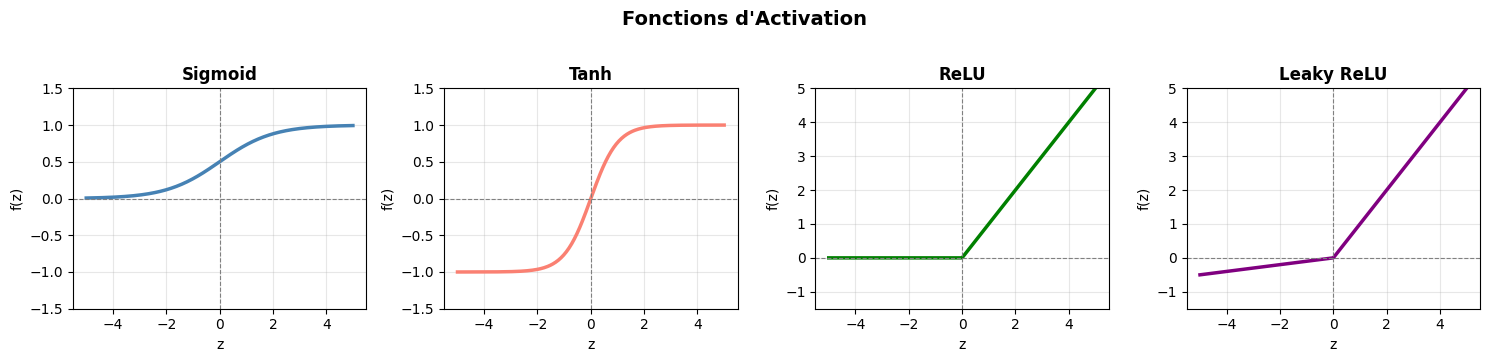

=== Simulation d'un neurone unique ===
Entrées x          : [ 2.   0.5 -1. ]
Poids   w          : [ 0.8  1.2 -0.5]
Biais   b          : 0.3
Somme pondérée z   : 3.0000
Sortie ReLU        : 3.0000
Sortie Sigmoid     : 0.9526


In [ ]:
# Exemple 18 — Fonctions d'activation et premier neurone
from sklearn.neural_network import MLPClassifier, MLPRegressor

# On crée 300 valeurs régulièrement espacées entre -5 et 5.
# Ces valeurs représentent toutes les entrées possibles z d'un neurone.
# C'est uniquement pour tracer les courbes — pas encore un vrai réseau.

z = np.linspace(-5, 5, 300)

# On calcule la sortie de chaque fonction d'activation pour chaque valeur de z.
# Chaque ligne applique la formule mathématique de la fonction sur tout le tableau z
# d'un coup grâce à NumPy (pas besoin de boucle).

activations = {
     # Sigmoid : compresse z dans [0, 1].
    'Sigmoid':    1 / (1 + np.exp(-z)),

    # Tanh : compresse z dans [-1, 1]. Disponible directement dans NumPy.
    'Tanh':       np.tanh(z),

    # ReLU : retourne z si z > 0, sinon retourne 0.
    'ReLU':       np.maximum(0, z),

    # Leaky ReLU : variante de ReLU qui ne coupe pas complètement les valeurs négatives.
    'Leaky ReLU': np.where(z > 0, z, 0.1 * z),
}

# On crée une figure avec 4 graphiques côte à côte (1 ligne, 4 colonnes).
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
couleurs = ['steelblue', 'salmon', 'green', 'purple']


# zip() combine les 3 listes en parallèle :
#   - axes       : les 4 sous-graphiques
#   - activations.items() : les paires (nom, valeurs_calculées)
#   - couleurs   : les 4 couleurs
# À chaque tour de boucle, ax = un graphique, nom = le nom, f = les valeurs, col = la couleur.
for ax, (nom, f), col in zip(axes, activations.items(), couleurs):

    # Trace la courbe : z en abscisse, f(z) en ordonnée
    ax.plot(z, f, color=col, linewidth=2.5)

    # Ajoute une ligne horizontale pointillée grise à y=0 (l'axe des abscisses)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

    # Ajoute une ligne verticale pointillée grise à x=0 (l'axe des ordonnées)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    # Titre du sous-graphique = nom de la fonction, en gras
    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel('z')        # z = l'entrée du neurone (la somme pondérée)
    ax.set_ylabel('f(z)')     # f(z) = la sortie après activation
    ax.grid(True, alpha=0.3)  # grille légère (alpha=0.3 → 30% d'opacité)

    # ReLU et Leaky ReLU ont des valeurs qui montent jusqu'à 5,
    # donc on agrandit l'axe y pour qu'elles soient bien visibles.
    # Sigmoid et Tanh restent entre -1 et 1, pas besoin d'autant de place.
    if nom in ('ReLU', 'Leaky ReLU'):
        ax.set_ylim(-1.5, 5)
    else:
        ax.set_ylim(-1.5, 1.5)

# Titre global au-dessus des 4 graphiques.
# y=1.02 le pousse légèrement au-dessus pour ne pas chevaucher les sous-titres.
plt.suptitle("Fonctions d'Activation", fontsize=14, fontweight='bold', y=1.02)

# Ajuste automatiquement les marges pour que les graphiques ne se chevauchent pas.
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# SIMULATION MANUELLE D'UN NEURONE UNIQUE
# On reproduit à la main ce qu'un neurone fait à l'intérieur d'un réseau.
print("=== Simulation d'un neurone unique ===")

# Les 3 entrées du neurone (par exemple : heures d'étude, heures de sommeil, note)
x = np.array([2.0, 0.5, -1.0])

# Les 3 poids associés à chaque entrée.
# Un poids fort (ex: 1.2) signifie que cette entrée a beaucoup d'influence.
# Un poids négatif (ex: -0.5) signifie que cette entrée diminue l'activation.
# Ces valeurs sont apprises automatiquement lors de l'entraînement.
w = np.array([0.8, 1.2, -0.5])

# Le biais : une constante ajoutée à la somme pondérée.
# Il permet au neurone de s'activer même si toutes les entrées sont à 0.
b = 0.3

# ÉTAPE 1 — Somme pondérée : z = w₁x₁ + w₂x₂ + w₃x₃ + b
# np.dot(w, x) calcule le produit scalaire : (0.8×2.0) + (1.2×0.5) + (-0.5×-1.0)
#                                           =  1.6      +  0.6      +  0.5
#                                           =  2.7
# Puis on ajoute le biais : 2.7 + 0.3 = 3.0
z_n = np.dot(w, x) + b

print(f"Entrées x          : {x}")
print(f"Poids   w          : {w}")
print(f"Biais   b          : {b}")
print(f"Somme pondérée z   : {z_n:.4f}")   # résultat avant activation

# ÉTAPE 2 — Fonction d'activation appliquée sur z_n
# Avec ReLU : max(0, 3.0) = 3.0  (z positif → on le garde tel quel)
print(f"Sortie ReLU        : {np.maximum(0, z_n):.4f}")

# Avec Sigmoid : 1 / (1 + e^(-3.0)) ≈ 0.9526
# Interprétation : 95.26% de probabilité que ce neurone "s'active"
print(f"Sortie Sigmoid     : {1/(1+np.exp(-z_n)):.4f}")

**Tâche 11.15** — Implémente manuellement un neurone avec la fonction d'activation ReLU :

1. Crée `x = np.array([1.5, -0.3, 2.0, 0.7])`, `w = np.array([0.4, -0.6, 0.2, 1.0])`, `b = -0.5`
2. Calcule la somme pondérée `z` avec `np.dot`
3. Applique ReLU, Sigmoid et Tanh sur `z`
4. Affiche `z` et les trois sorties
5. Explique dans un commentaire : **pourquoi ReLU est préféré à Sigmoid pour les couches cachées ?**

In [ ]:
# Tâche 11.15


### 8.2 MLPClassifier — Classification avec un réseau de neurones

Scikit-learn fournit `MLPClassifier` et `MLPRegressor`. Ils suivent exactement la même interface que tous les autres modèles sklearn (`fit`, `predict`, `score`).

**Principaux hyperparamètres :**

| Paramètre | Description | Défaut |
|---|---|---|
| `hidden_layer_sizes` | Taille de chaque couche cachée, ex: `(100, 50)` | `(100,)` |
| `activation` | Fonction d'activation : `'relu'`, `'tanh'`, `'logistic'` | `'relu'` |
| `solver` | Algorithme d'optimisation : `'adam'`, `'sgd'`, `'lbfgs'` | `'adam'` |
| `alpha` | Coefficient de régularisation L2 (évite l'overfitting) | `0.0001` |
| `learning_rate_init` | Taux d'apprentissage initial | `0.001` |
| `max_iter` | Nombre maximum d'époques | `200` |
| `early_stopping` | Arrêt si la validation ne s'améliore plus | `False` |

**Les solveurs :**
- **`'adam'`** : adapte le learning rate automatiquement. Très efficace. **Recommandé.**
- **`'sgd'`** : descente de gradient stochastique classique. Plus de réglages nécessaires.
- **`'lbfgs'`** : méthode quasi-Newton, très bon pour les petits datasets.


Accuracy MLP         : 1.0000
Nombre d'époques     : 277
Loss finale          : 0.010057
Architecture (poids) : [(3, 64), (64, 32), (32, 1)]

Rapport de classification :
              precision    recall  f1-score   support

      Refusé       1.00      1.00      1.00        45
       Admis       1.00      1.00      1.00        35

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



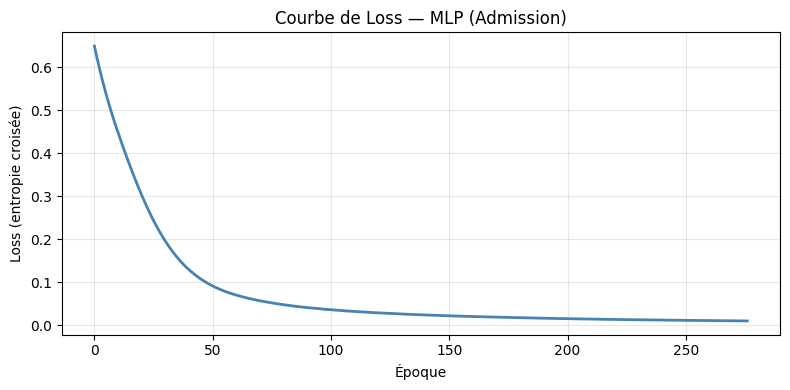

In [ ]:
# Exemple 19 — MLPClassifier sur le dataset admission
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
n = 400

# Dataset admission (réutilisé depuis la Partie 3)
heures_etude    = np.random.uniform(0, 12, n)
heures_sommeil  = np.random.uniform(4, 10, n)
note_precedente = np.random.uniform(5, 20, n)
score_adm = heures_etude * 1.2 + heures_sommeil * 0.4 + note_precedente * 0.5
admis = (score_adm > score_adm.mean()).astype(int)

# x_adm : X admin
# y_adm : y admin
# Xtr_adm : Xtrain admin

X_adm = np.column_stack([heures_etude, heures_sommeil, note_precedente])
y_adm = admis

Xtr_adm, Xte_adm, ytr_adm, yte_adm = train_test_split(X_adm, y_adm, test_size=0.2, random_state=42)
sc_adm = StandardScaler()
Xtr_adm_s = sc_adm.fit_transform(Xtr_adm)
Xte_adm_s = sc_adm.transform(Xte_adm)

# Créer le MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 couches cachées : 64 puis 32 neurones
    activation='relu',
    solver='adam',
    alpha=0.001,                   # régularisation L2
    max_iter=500,
    random_state=42
)

mlp.fit(Xtr_adm_s, ytr_adm)

y_pred_mlp = mlp.predict(Xte_adm_s)
print(f"Accuracy MLP         : {accuracy_score(yte_adm, y_pred_mlp):.4f}")
print(f"Nombre d'époques     : {mlp.n_iter_}")
print(f"Loss finale          : {mlp.loss_:.6f}")
print(f"Architecture (poids) : {[w.shape for w in mlp.coefs_]}")
print("\nRapport de classification :")
print(classification_report(yte_adm, y_pred_mlp, target_names=['Refusé', 'Admis']))

# Courbe de loss
# loss_curve_ enregistre la valeur de l'erreur après chaque époque.
# Une courbe qui descend régulièrement = bon apprentissage.
# Une courbe qui stagne ou remonte = problème (mauvais learning rate, overfitting, …)
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color='steelblue', linewidth=2)
plt.title("Courbe de Loss — MLP (Admission)", fontsize=12)
plt.xlabel('Époque')
plt.ylabel('Loss (entropie croisée)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Comparaison d'architectures et courbes de loss

La **courbe de loss** montre comment l'erreur évolue au fil des époques :
- **Courbe qui descend régulièrement** → bon entraînement
- **Courbe qui stagne tôt** → modèle trop petit ou learning rate trop faible
- **Courbe qui oscille beaucoup** → learning rate trop grand


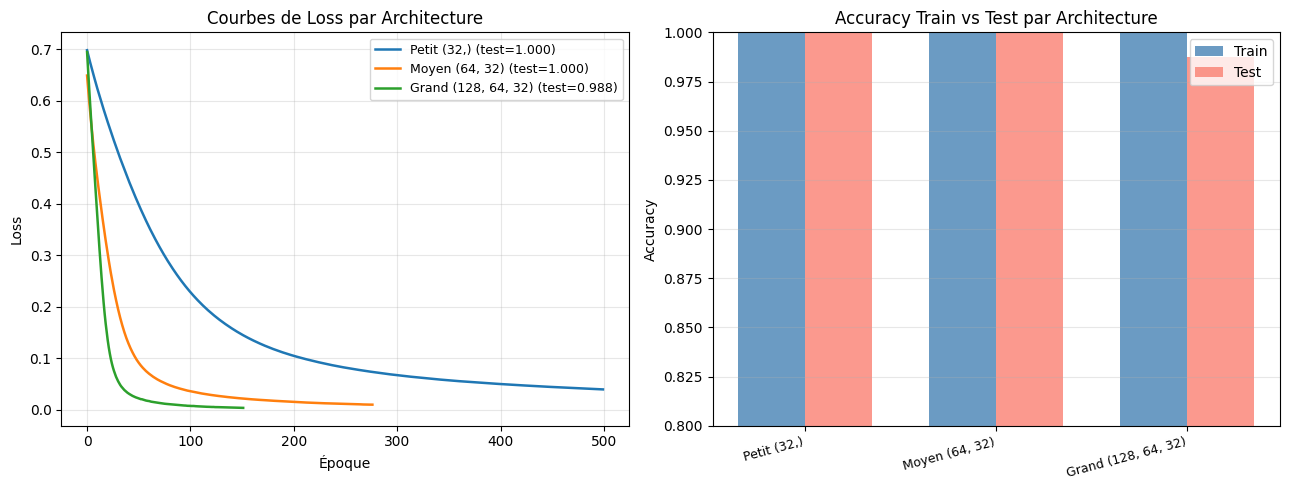


Architecture                   Train       Test
-----------------------------------------------
Petit (32,)                   1.0000     1.0000
Moyen (64, 32)                1.0000     1.0000
Grand (128, 64, 32)           1.0000     0.9875


In [ ]:
# Exemple 20 — Comparaison d'architectures MLP

# Les 3 architectures à comparer.
# Un tuple à 1 élément → 1 couche cachée : (32,) = une couche de 32 neurones
# Un tuple à 2 éléments → 2 couches cachées : (64, 32) = 64 puis 32 neurones
# Un tuple à 3 éléments → 3 couches cachées : (128, 64, 32)
architectures = {
    'Petit (32,)':          (32,),
    'Moyen (64, 32)':      (64, 32),
    'Grand (128, 64, 32)': (128, 64, 32),
}

# Figure avec 2 graphiques côte à côte :
# axes[0] → courbes de loss | axes[1] → barres accuracy train vs test
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Dictionnaire pour stocker les résultats : {'nom': (acc_train, acc_test)}
resultats_archi = {}

# On entraîne un MLP par architecture
for nom, archi in architectures.items():
    m = MLPClassifier(
        hidden_layer_sizes=archi,
        activation='relu', solver='adam',
        alpha=0.001, max_iter=500, random_state=42
    )
    m.fit(Xtr_adm_s, ytr_adm)

    # Accuracy sur train ET test
    acc_tr = accuracy_score(ytr_adm, m.predict(Xtr_adm_s))
    acc_te = accuracy_score(yte_adm, m.predict(Xte_adm_s))
    resultats_archi[nom] = (acc_tr, acc_te)
    axes[0].plot(m.loss_curve_, label=f'{nom} (test={acc_te:.3f})', linewidth=1.8)

#Graphique  : courbes de loss
axes[0].set_title('Courbes de Loss par Architecture', fontsize=12)
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Graphique : barres groupées accuracy train vs test
# On extrait les listes de scores depuis le dictionnaire
noms = list(resultats_archi.keys())
acc_tr_list = [v[0] for v in resultats_archi.values()]
acc_te_list = [v[1] for v in resultats_archi.values()]
x_pos = np.arange(len(noms))
w = 0.35  # largeur de chaque barre

axes[1].bar(x_pos - w/2, acc_tr_list, w, label='Train', color='steelblue', alpha=0.8)
axes[1].bar(x_pos + w/2, acc_te_list, w, label='Test',  color='salmon',    alpha=0.8)
axes[1].set_xticks(x_pos)

# rotation=15 incline les étiquettes pour qu'elles ne se chevauchent pas
axes[1].set_xticklabels(noms, rotation=15, ha='right', fontsize=9)
axes[1].set_ylim(0.8, 1.0)
axes[1].set_title('Accuracy Train vs Test par Architecture', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].legend()
# axis='y' : grille uniquement sur les lignes horizontales
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ─Tableau récapitulatif
print(f"\n{'Architecture':<25} {'Train':>10} {'Test':>10}")
print("-" * 47)
for nom, (tr, te) in resultats_archi.items():
    print(f"{nom:<25} {tr:>10.4f} {te:>10.4f}")

**Tâche 11.16** — Avec le dataset admission (`Xtr_adm_s`, `Xte_adm_s`, `ytr_adm`, `yte_adm`) :

1. Entraîne 3 MLP avec les fonctions d'activation `'relu'`, `'tanh'`, `'logistic'` (architecture `(64, 32)`, `max_iter=500`)
2. Pour chaque activation, affiche accuracy train et test et trace les courbes de loss sur un même graphique
3. Quelle activation converge le plus vite ? Laquelle donne le meilleur résultat sur le test ?
4. Explique dans un commentaire pourquoi `'logistic'` (sigmoid) peut être plus lente à converger que `'relu'`

In [ ]:
# Tâche 11.16


### 8.4 MLPRegressor — Régression avec un réseau de neurones

`MLPRegressor` fonctionne exactement comme `MLPClassifier`, mais pour prédire des valeurs continues. Sa vraie puissance par rapport à la régression linéaire, c'est sa capacité à modéliser des **relations non-linéaires complexes** sans qu'on ait besoin de les spécifier manuellement.


Modèle                        R² Train      R² Test
---------------------------------------------------
Régression Linéaire             0.1093       0.1433
MLP (64, 32)                    0.9516       0.9525
MLP (128, 64, 32)               0.9582       0.9626


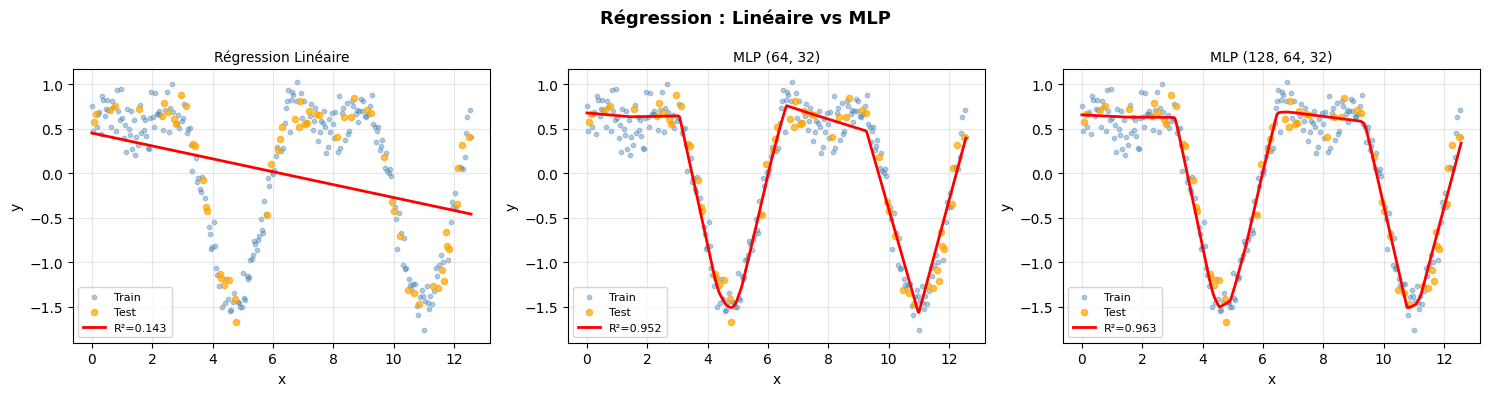

In [ ]:
# Exemple 21 — MLPRegressor sur une fonction non-linéaire complexe
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(7)
n = 300

# Fonction complexe : somme de sinusoïdes
# 300 valeurs de x régulièrement espacées entre 0 et 4π
x_r = np.linspace(0, 4 * np.pi, n)

y_r = np.sin(x_r) + 0.5 * np.cos(2 * x_r) + np.random.normal(0, 0.15, n)

# reshape(-1, 1) : sklearn attend une matrice 2D en entrée.
# x_r a la forme (300,) → on la transforme en (300, 1) : 300 lignes, 1 colonne.
X_r = x_r.reshape(-1, 1)
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(X_r, y_r, test_size=0.2, random_state=7)

sc_r = StandardScaler()
Xtr_r_s = sc_r.fit_transform(Xtr_r)
Xte_r_s = sc_r.transform(Xte_r)

# Les 3 modèles à comparer
# max_iter=1000 pour les MLP : la courbe ondulée est complexe,
# on donne plus d'époques pour que le réseau ait le temps d'apprendre.
modeles_reg = {
    'Régression Linéaire'  : LinearRegression(),
    'MLP (64, 32)'         : MLPRegressor(hidden_layer_sizes=(64, 32),  activation='relu', max_iter=1000, random_state=7),
    'MLP (128, 64, 32)'    : MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu', max_iter=1000, random_state=7),
}

print(f"{'Modèle':<25} {'R² Train':>12} {'R² Test':>12}")
print("-" * 51)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Points denses pour tracer une courbe lisse des prédictions.
# On crée 500 valeurs de x (plus que les 300 du dataset) pour que la courbe
# tracée soit bien fluide, sans angles ni sauts visibles.
x_vis = np.linspace(0, 4*np.pi, 500).reshape(-1, 1)
x_vis_s = sc_r.transform(x_vis)


# Boucle : entraînement + visualisation pour chaque modèle
# zip(axes, modeles_reg.items()) associe chaque modèle à son graphique
for ax, (nom, mod) in zip(axes, modeles_reg.items()):
    mod.fit(Xtr_r_s, ytr_r)
    r2_tr = r2_score(ytr_r, mod.predict(Xtr_r_s))
    r2_te = r2_score(yte_r, mod.predict(Xte_r_s))
    print(f"{nom:<25} {r2_tr:>12.4f} {r2_te:>12.4f}")

    ax.scatter(Xtr_r, ytr_r, s=10, alpha=0.4, color='steelblue', label='Train')
    ax.scatter(Xte_r, yte_r, s=20, alpha=0.7, color='orange', label='Test')

    # Courbe de prédiction en rouge : on prédit sur les 500 points de x_vis
    # pour obtenir une courbe lisse qui montre ce que le modèle a appris
    ax.plot(x_vis, mod.predict(x_vis_s), 'r-', linewidth=2, label=f'R²={r2_te:.3f}')
    ax.set_title(nom, fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Régression : Linéaire vs MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Tâche 11.17** — Utilise le dataset maisons de la Tâche 11.1 (surface, nb_pieces, age) avec les données normalisées de la Tâche 11.2.

1. Entraîne 3 modèles : `LinearRegression`, `MLPRegressor(64, 32)`, `MLPRegressor(128, 64, 32)` avec `max_iter=1000`
2. Calcule MAE, RMSE, R² pour chaque modèle sur le test set
3. Crée un DataFrame récapitulatif des métriques
4. Trace les courbes de loss des deux MLP sur un même graphique
5. Le MLP apporte-t-il un gain par rapport à la régression linéaire ? Pourquoi ou pourquoi pas ?

In [ ]:
# Tâche 11.17


### 8.5 Régularisation et Overfitting dans les MLP

Un MLP avec beaucoup de neurones possède des **millions de paramètres**. Avec autant de degrés de liberté, il peut facilement mémoriser les données d'entraînement plutôt que d'apprendre des patterns généraux.

**Techniques de régularisation :**

- **Régularisation L2 (`alpha`)** : pénalise les gros poids, identique à Ridge. Plus `alpha` est grand, plus les poids sont contraints.
- **Early Stopping** : on surveille un score de validation pendant l'entraînement. Si le score ne s'améliore plus après `n_iter_no_change` époques, on stoppe.
- **Architecture adaptée** : ne pas mettre un réseau trop grand par rapport à la quantité de données.


Scénario                                 Train       Test     Overfit?
---------------------------------------------------------------------
Overfitting (grand réseau, alpha faible)     1.0000     0.8667 OUI ⚠️ (fort)
Régularisation (alpha=0.1)              1.0000     0.9000 OUI (modéré)
Early Stopping                          0.7556     0.7333        non ✓
Architecture adaptée (32,)              0.9778     0.8667 OUI ⚠️ (fort)


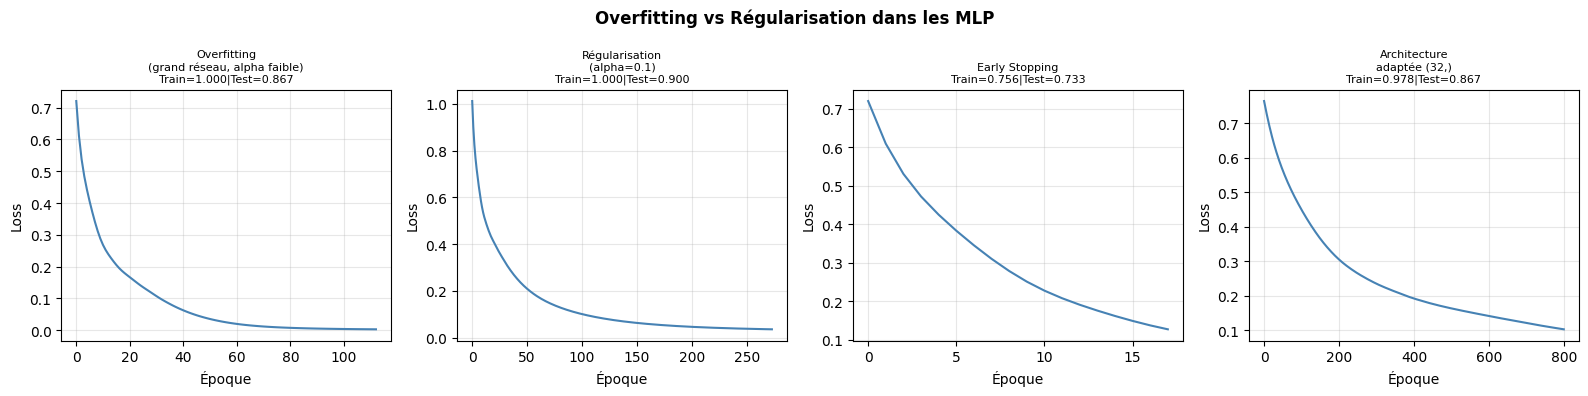

In [ ]:
# Exemple 22 — Overfitting et techniques de régularisation
np.random.seed(0)

# Création d'un petit dataset pour provoquer l'overfitting
# Seulement 120 exemples avec 5 features : trop peu pour un grand réseau.
n_small = 120
X_ov = np.random.randn(n_small, 5) # 120 lignes × 5 colonnes, valeurs aléatoires

# La règle de classification utilise seulement les colonnes 0, 2 et 4.
# Les colonnes 1 et 3 sont du bruit pur, un modèle trop grand va quand même
# essayer de les mémoriser, ce qui cause l'overfitting.
# X_ov[:, 2]**2 introduit une non-linéarité (terme au carré).
y_ov = (X_ov[:, 0] + X_ov[:, 2]**2 - X_ov[:, 4] > 0).astype(int)

Xtr_ov, Xte_ov, ytr_ov, yte_ov = train_test_split(X_ov, y_ov, test_size=0.25, random_state=0)
sc_ov = StandardScaler()
Xtr_ov_s = sc_ov.fit_transform(Xtr_ov)
Xte_ov_s = sc_ov.transform(Xte_ov)

#Les 4 scénarios à comparer
scenarios = {
    # Scénario 1 — Overfitting volontaire
    # Réseau énorme (512×512 = ~260 000 paramètres) pour seulement 90 exemples d'entraînement.
    # alpha très faible = presque pas de régularisation → le réseau mémorise les données.
    'Overfitting\n(grand réseau, alpha faible)': MLPClassifier(
        hidden_layer_sizes=(512, 512), alpha=0.00001, max_iter=800, random_state=0),

     # Scénario 2 — Régularisation L2 (même réseau, alpha plus fort)
    # On garde le même grand réseau mais on augmente alpha de 0.00001 à 0.1.
    # La pénalité force les poids à rester petits → le réseau généralise mieux.
    'Régularisation\n(alpha=0.1)': MLPClassifier(
        hidden_layer_sizes=(512, 512), alpha=0.1, max_iter=800, random_state=0),

    # Scénario 3 — Early Stopping
    # Même grand réseau sans régularisation, mais on surveille la performance
    # sur une fraction de validation (15% du train).
    # Si le score ne s'améliore pas pendant 15 époques d'affilée → on stoppe.
    # Le réseau s'arrête avant d'avoir le temps de mémoriser.
    'Early Stopping': MLPClassifier(
        hidden_layer_sizes=(512, 512), alpha=0.00001, max_iter=800,
        early_stopping=True, n_iter_no_change=15, validation_fraction=0.15, random_state=0),

    # Scénario 4 — Architecture adaptée à la taille du dataset
    # Un petit réseau (32 neurones, 1 couche) a bien moins de paramètres.
    # Moins de capacité = moins de risque de mémorisation.
    'Architecture\nadaptée (32,)': MLPClassifier(
        hidden_layer_sizes=(32,), alpha=0.001, max_iter=800, random_state=0),
}

print(f"{'Scénario':<35} {'Train':>10} {'Test':>10} {'Overfit?':>12}")
print("-" * 69)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (nom, mod) in zip(axes, scenarios.items()):
    mod.fit(Xtr_ov_s, ytr_ov)
    tr = accuracy_score(ytr_ov, mod.predict(Xtr_ov_s))
    te = accuracy_score(yte_ov, mod.predict(Xte_ov_s))
    # Si l'écart entre train et test dépasse 5 points → overfitting détecté.
    # Ex : train=0.97, test=0.71 → écart=0.26 → OUI
    overfit = "OUI ⚠️ (fort)" if (tr - te) > 0.1 else "OUI (modéré)" if (tr - te) > 0.05 else "non ✓"
    nom_print = nom.replace('\n', ' ')
    print(f"{nom_print:<35} {tr:>10.4f} {te:>10.4f} {overfit:>12}")
    # La courbe de loss révèle le comportement de l'entraînement :
    # Overfitting → loss descend très bas (le réseau mémorise)
    # Early stopping → courbe s'arrête tôt
    # Bonne régularisation → descente régulière et stable
    ax.plot(mod.loss_curve_, color='steelblue', linewidth=1.5)
    ax.set_title(f'{nom}\nTrain={tr:.3f}|Test={te:.3f}', fontsize=8)
    ax.set_xlabel('Époque')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

plt.suptitle('Overfitting vs Régularisation dans les MLP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Tâche 11.18** — Utilise le dataset maisons normalisé (Tâche 11.2).

1. Entraîne 5 `MLPRegressor` avec `alpha` croissant : `[0.00001, 0.0001, 0.01, 0.1, 1.0]` (architecture `(64, 32)`, `max_iter=1000`)
2. Pour chaque `alpha`, affiche R² train et R² test
3. Trace R² train et R² test en fonction de log(alpha) sur un même graphique
4. Entraîne un MLP avec `early_stopping=True` et affiche le nombre d'itérations effectuées (`n_iter_`)
5. Quel `alpha` donne le meilleur compromis ? Que se passe-t-il quand `alpha` est trop grand ?

In [ ]:
# Tâche 11.18


### 8.6 MLP dans un Pipeline + GridSearchCV

Le MLP s'intègre parfaitement dans un `Pipeline` — avec la syntaxe `'mlp__hidden_layer_sizes'` (double underscore) pour accéder aux hyperparamètres depuis GridSearchCV.


In [ ]:
# Exemple 23 — Pipeline MLP + GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline : StandardScaler → MLP
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(max_iter=500, random_state=42))
])

# Grille d'hyperparamètres
param_grid_mlp = {
    'mlp__hidden_layer_sizes' : [(32,), (64, 32), (128, 64)],
    'mlp__activation'         : ['relu', 'tanh'],
    'mlp__alpha'              : [0.0001, 0.01],
}

print("Lancement du GridSearch (12 combinaisons × 5 folds)...")
grid_mlp = GridSearchCV(
    pipe_mlp, param_grid_mlp,
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_mlp.fit(Xtr_adm, ytr_adm)  # le Pipeline gère le scaling

print(f"\nMeilleurs paramètres :")
for k, v in grid_mlp.best_params_.items():
    print(f"  {k:<35} : {v}")
print(f"\nMeilleur score CV   : {grid_mlp.best_score_:.4f}")
print(f"Score sur test set  : {grid_mlp.score(Xte_adm, yte_adm):.4f}")

# Top 5 configurations
results_gs = pd.DataFrame(grid_mlp.cv_results_)
top5 = results_gs.sort_values('rank_test_score').head(5)[[
    'param_mlp__hidden_layer_sizes', 'param_mlp__activation',
    'param_mlp__alpha', 'mean_test_score', 'std_test_score'
]].reset_index(drop=True)
top5.columns = ['Architecture', 'Activation', 'Alpha', 'Score Moy.', 'Std']
print("\nTop 5 configurations :")
print(top5.to_string())

Lancement du GridSearch (12 combinaisons × 5 folds)...

Meilleurs paramètres :
  mlp__activation                     : relu
  mlp__alpha                          : 0.0001
  mlp__hidden_layer_sizes             : (32,)

Meilleur score CV   : 0.9938
Score sur test set  : 1.0000

Top 5 configurations :
  Architecture Activation   Alpha  Score Moy.       Std
0        (32,)       relu  0.0001     0.99375  0.007655
1    (128, 64)       relu  0.0001     0.99375  0.007655
2        (32,)       relu  0.0100     0.99375  0.007655
3    (128, 64)       relu  0.0100     0.99375  0.007655
4     (64, 32)       tanh  0.0001     0.99375  0.007655


**Tâche 11.19** — Utilise le dataset **Breast Cancer** (`load_breast_cancer()`) de scikit-learn (569 tumeurs, 30 features, 2 classes : malin / bénin).

1. Charge le dataset, effectue un split 80/20 stratifié
2. Crée un Pipeline `StandardScaler → MLPClassifier`
3. Lance un `GridSearchCV` avec :
   - `hidden_layer_sizes` : `[(64, 32), (128, 64)]`
   - `alpha` : `[0.0001, 0.001, 0.01]`
   - `activation` : `['relu', 'tanh']`
   - `cv=5`, `scoring='f1'`
4. Affiche les meilleurs paramètres et le score CV
5. Évalue sur le test set : accuracy, F1, matrice de confusion
6. Compare avec `RandomForestClassifier(n_estimators=100)` — lequel est meilleur ?

In [ ]:
# Tâche 11.19


---
## Conclusion

Dans cette leçon, tu as acquis les bases fondamentales du Machine Learning avec Scikit-Learn :

**Préparation des données** : train/test split, normalisation (StandardScaler, MinMaxScaler), encodage catégoriel

**Régression** : Linéaire, Polynomiale, Ridge, Lasso — prédire des valeurs continues

**Classification** : Régression Logistique, KNN, Arbre de Décision, Random Forest — prédire des catégories

**Évaluation** : métriques de régression (MAE, RMSE, R²), métriques de classification (accuracy, précision, rappel, F1), matrice de confusion, cross-validation

**Optimisation** : GridSearchCV pour trouver les meilleurs hyperparamètres

**Non supervisé** : K-Means clustering

**Pipelines** : automatiser et sécuriser le flux de travail ML

**Réseaux de neurones (MLP)** : `MLPClassifier`, `MLPRegressor`, fonctions d'activation, architectures, régularisation, courbes de loss

> **Rappel clé** : l'interface de scikit-learn est toujours la même — `fit()`, `predict()`, `score()`. Une fois que tu maîtrises cette logique, tu peux utiliser n'importe quel algorithme de la même façon — y compris les réseaux de neurones.

---
## Problèmes


### Problème 1 — Prédiction des Prix de l'Immobilier avec Scikit-Learn

Utilise le dataset `fetch_california_housing()` de scikit-learn (logements en Californie).

a. **Exploration** : charge le dataset, affiche les dimensions, les noms des features et leur description. Calcule les statistiques descriptives avec Pandas et visualise la distribution de la variable cible (prix médian).

b. **Préparation** : vérifie les valeurs manquantes. Effectue un split 80/20. Normalise les données.

c. **Modélisation** : entraîne et évalue les modèles suivants avec les métriques MAE, RMSE et R² :
   - `LinearRegression`
   - `Ridge` avec plusieurs valeurs d'alpha
   - `RandomForestRegressor(n_estimators=100)`

d. **Optimisation** : utilise `GridSearchCV` sur le `RandomForestRegressor` avec la grille : `n_estimators`=[50,100,200], `max_depth`=[None,5,10], `min_samples_split`=[2,5].

e. **Analyse des features** : affiche l'importance des features du meilleur Random Forest sous forme de graphique à barres horizontales.

f. **Visualisation** : trace un scatter plot "valeurs réelles vs valeurs prédites" pour le meilleur modèle. Ajoute la ligne parfaite y=x. Quels types de logements sont les plus mal prédits ?

g. **Rapport final** : crée un DataFrame récapitulatif comparant tous les modèles testés.

In [ ]:
# Problème 1


### Problème 2 — Projet ML Complet : Système de Détection de Maladies Cardiaques

Ce problème simule un projet ML de bout en bout pour prédire si un patient est à risque de maladie cardiaque.

Le dataset **`dataset_patient.csv`** est disponible dans le même dossier que ce notebook.

**Étapes obligatoires :**

a. **Exploration des données** :
   - Statistiques descriptives par classe (malade / non-malade)
   - Taux de maladie par tranche d'âge (20-40, 41-55, 56-70, >70)
   - Visualisation : histogrammes comparatifs, scatter plots des features les plus corrélées à la maladie

b. **Préparation** :
   - Encode `type_douleur` avec `pd.get_dummies`
   - Split 75/25 (stratifié : `stratify=y` dans `train_test_split` pour garder les proportions)
   - Normalise avec `StandardScaler`

c. **Pipeline + GridSearch** : construis un Pipeline pour chacun des modèles suivants et trouve les meilleurs hyperparamètres avec `GridSearchCV` (5-fold, scoring='f1') :
   - `LogisticRegression` (C=[0.01, 0.1, 1, 10])
   - `KNeighborsClassifier` (n_neighbors=[3,5,7,10], weights=['uniform','distance'])
   - `RandomForestClassifier` (n_estimators=[50,100], max_depth=[None,5,8])
   - `MLPClassifier` (hidden_layer_sizes=[(64,32),(128,64)], alpha=[0.0001,0.01])

d. **Évaluation et comparaison** :
   - Tableau comparatif : accuracy, précision, rappel, F1, score CV moyen pour les **4 modèles**
   - Matrice de confusion pour le meilleur modèle
   - Courbe ROC (utilise `RocCurveDisplay`) pour les 4 modèles

e. **Seuil de classification** : la régression logistique donne une probabilité. En médecine, il vaut mieux avoir des faux positifs (dire malade à quelqu'un de sain) que des faux négatifs (manquer une vraie maladie). Teste des seuils de 0.3, 0.4, 0.5, 0.6 et observe comment précision et rappel évoluent. Fais la même chose avec le **MLP**.

f. **Analyse des courbes de loss du MLP** :
   - Trace la courbe de loss du meilleur MLP
   - Le MLP fait-il de l'overfitting ? Comment le détecter ?

g. **Conclusion** : rédige dans une cellule Markdown ton analyse des résultats. Quel modèle recommanderais-tu en contexte médical ? Le MLP apporte-t-il un gain par rapport aux modèles classiques ? Justifie en utilisant les métriques.


In [ ]:
# Problème 2 — Génération du dataset


In [ ]:
# Problème 2a — Exploration


In [ ]:
# Problème 2b — Préparation


In [ ]:
# Problème 2c — Pipelines + GridSearch (LogReg, KNN, RF, MLP)


In [ ]:
# Problème 2d — Évaluation et comparaison


In [ ]:
# Problème 2e — Seuil de classification (LogReg + MLP)


In [ ]:
# Problème 2f — Courbes de loss du MLP


### Problème 2g — Conclusion et recommandation

*Écris ici ton analyse...*
